# Hafta 1 · Yapay Zekâ Tıbbı Nasıl Dönüştürüyor? İlk Kod

**Yapay Zeka ve Sağlık** · Fırat Üniversitesi Tıp Fakültesi

Bu defter dersin ilk saatinde birlikte çalıştıracağımız kodları içerir. Hiçbir şey kurmanız gerekmez:
sağ üstteki **Bağlan** düğmesine basın, sonra her hücrenin solundaki ▶ simgesine tıklayın (veya `Shift+Enter`).

> Amaç bugün Python öğrenmek değil; *bir hekimin tarayıcıdan çıkmadan gerçek veriyle ve yapay zekâyla neler yapabildiğini* görmek.


## 0 · Merhaba

Bilgisayara bir şey söyletmek için `print()` kullanırız. Tırnak içindeki metni ekrana yazar.

In [1]:
print("Merhaba! Bu ders için yazdığım ilk satır.")

Merhaba! Bu ders için yazdığım ilk satır.


Şimdi adınızı yazın ve çalıştırın. Hata alırsanız korkmayın; hata mesajı bize ne olduğunu söyler.

In [2]:
ad = "Adınızı buraya yazın"
print("Merhaba", ad, "— Yapay Zeka ve Sağlık dersine hoş geldin.")

Merhaba Adınızı buraya yazın — Yapay Zeka ve Sağlık dersine hoş geldin.


## 1 · Hesap makinesinden fazlası: ilk klinik hesap

Bir hastanın kilosu ve boyu var. Vücut kitle indeksini (VKİ) elle hesaplamak yerine bilgisayara hesaplatıyoruz.
`kilo` ve `boy` birer **değişken**: bir değeri isimle saklayan kutu.

In [3]:
kilo = 82      # kg
boy = 1.74     # m

vki = kilo / boy ** 2
print("VKİ:", round(vki, 1))

if vki < 18.5:
    print("Zayıf")
elif vki < 25:
    print("Normal")
elif vki < 30:
    print("Fazla kilolu")
else:
    print("Obez")

VKİ: 27.1
Fazla kilolu


> **Deneyin:** `kilo` değerini 60 yapın ve hücreyi yeniden çalıştırın. Sınıflama değişti mi?

## 2 · Tek hasta değil, tüm servis

Asıl güç, aynı işlemi yüzlerce hasta için tek seferde yapabilmekte. Aşağıda 8 hastanın kilo/boy listesi var.
Bir **döngü** ile hepsini dolaşıyoruz.

In [4]:
hastalar = [
    ("H1", 82, 1.74), ("H2", 58, 1.62), ("H3", 95, 1.80), ("H4", 70, 1.68),
    ("H5", 110, 1.71), ("H6", 49, 1.60), ("H7", 77, 1.85), ("H8", 88, 1.66),
]

for kod, kilo, boy in hastalar:
    vki = kilo / boy ** 2
    uyari = "  ← dikkat" if vki >= 30 else ""
    print(f"{kod}: VKİ {vki:4.1f}{uyari}")

H1: VKİ 27.1
H2: VKİ 22.1
H3: VKİ 29.3
H4: VKİ 24.8
H5: VKİ 37.6  ← dikkat
H6: VKİ 19.1
H7: VKİ 22.5
H8: VKİ 31.9  ← dikkat


## 3 · Gerçek bir sağlık veri seti, 3 satırda

Şimdi internetten gerçek bir veri seti indiriyoruz: **Pima Kızılderilileri Diyabet Veri Seti** (768 kadın hasta,
glukoz, kan basıncı, VKİ, yaş ve diyabet tanısı). Bu, dünyada makine öğrenmesi öğretiminde en çok kullanılan tıbbi veri setlerinden biri.

`pandas` kütüphanesi tablo verisiyle çalışmak için; Excel gibi düşünün ama programlanabilir.

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
sutunlar = ["gebelik", "glukoz", "kan_basinci", "cilt_kalinligi", "insulin", "vki", "soyagaci", "yas", "diyabet"]

try:
    df = pd.read_csv(url, names=sutunlar)
except Exception as e:  # çevrimdışı çalışıyorsak küçük bir örnek üret
    import numpy as np
    rng = np.random.default_rng(0)
    df = pd.DataFrame({"gebelik": rng.integers(0, 10, 768), "glukoz": rng.normal(120, 30, 768).round(),
        "kan_basinci": rng.normal(70, 12, 768).round(), "cilt_kalinligi": rng.normal(20, 10, 768).round(),
        "insulin": rng.normal(80, 100, 768).clip(0).round(), "vki": rng.normal(32, 7, 768).round(1),
        "soyagaci": rng.random(768).round(3), "yas": rng.integers(21, 70, 768), "diyabet": rng.integers(0, 2, 768)})
    print("İnternet yok; sentetik örnek veri kullanılıyor.")

print("Satır sayısı (hasta):", len(df))
df.head()

Satır sayısı (hasta): 768


,gebelik,glukoz,kan_basinci,cilt_kalinligi,insulin,vki,soyagaci,yas,diyabet
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Her satır bir hasta, her sütun bir ölçüm. Son sütun `diyabet`: 1 = tanı var, 0 = yok.

Bir bakışta özet istatistik:

In [6]:
df.describe().round(1)

,gebelik,glukoz,kan_basinci,cilt_kalinligi,insulin,vki,soyagaci,yas,diyabet
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,3.8,120.9,69.1,20.5,79.8,32.0,0.5,33.2,0.3
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.3,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.5,32.0,0.4,29.0,0.0
75%,6.0,140.2,80.0,32.0,127.2,36.6,0.6,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0,1.0


**Klinik soru:** Diyabetli hastaların glukoz ortalaması diyabetsizlerden ne kadar farklı? Elle saatler sürecek işlem, tek satır:

In [7]:
df.groupby("diyabet")[["glukoz", "vki", "yas"]].mean().round(1)

,glukoz,vki,yas
diyabet,,,
0,110.0,30.3,31.2
1,141.3,35.1,37.1


## 4 · Veriyi görmek

Sayı tablosu yerine grafik. Glukoz dağılımını diyabet durumuna göre çiziyoruz.

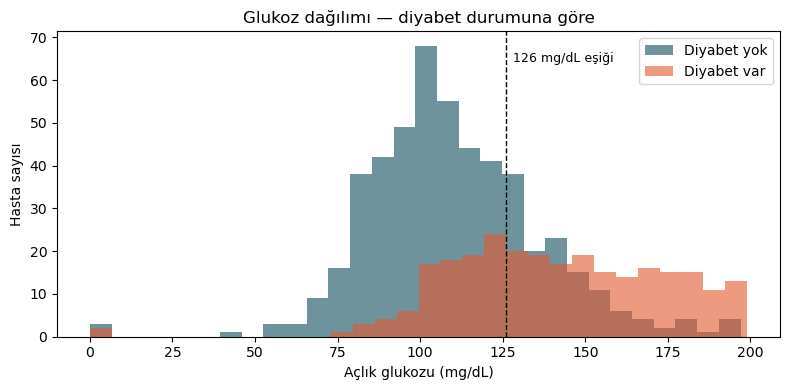

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for etiket, renk, ad in [(0, "#0f4c5c", "Diyabet yok"), (1, "#e4572e", "Diyabet var")]:
    ax.hist(df.loc[df.diyabet == etiket, "glukoz"], bins=30, alpha=0.6, color=renk, label=ad)
ax.axvline(126, color="black", linestyle="--", linewidth=1)
ax.text(128, ax.get_ylim()[1] * 0.9, "126 mg/dL eşiği", fontsize=9)
ax.set_xlabel("Açlık glukozu (mg/dL)")
ax.set_ylabel("Hasta sayısı")
ax.set_title("Glukoz dağılımı — diyabet durumuna göre")
ax.legend()
plt.tight_layout()
plt.show()

> **Tartışma:** İki dağılım örtüşüyor. Tek başına glukoz tanı koymaya yeter mi? Bu örtüşme, ileride öğreneceğimiz *duyarlılık/özgüllük* kavramının ta kendisi.

## 5 · Bir dakikada "yapay zekâ": bilgisayar kendi kuralını öğreniyor

Şimdiye kadar kuralı **biz** yazdık (VKİ eşikleri). Makine öğrenmesinde kuralı **veri** yazar.
Aşağıda bilgisayara 768 hastanın verisini verip "diyabeti tahmin et" diyoruz. Bunun nasıl çalıştığını
12–13. haftalarda öğreneceğiz; bugün sadece *olabildiğini* görüyoruz.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[["glukoz", "vki", "yas", "kan_basinci"]]
y = df["diyabet"]

X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_egitim, y_egitim)               # ← öğrenme burada oluyor

dogruluk = model.score(X_test, y_test)
print(f"Modelin hiç görmediği {len(X_test)} hastada doğruluk: %{dogruluk*100:.0f}")

Modelin hiç görmediği 231 hastada doğruluk: %72


Yeni bir hasta gelsin: 55 yaşında, glukoz 150, VKİ 33, kan basıncı 80. Model ne diyor?

In [10]:
yeni_hasta = pd.DataFrame([[150, 33, 55, 80]], columns=X.columns)
olasilik = model.predict_proba(yeni_hasta)[0, 1]
print(f"Diyabet olasılığı: %{olasilik*100:.0f}")

Diyabet olasılığı: %76


> **Dikkat:** Bu %'lik bir *tanı* değil, bir *olasılık*. Modelin kimlerde yanıldığını, hangi gruplarda kötü çalıştığını bilmeden klinikte kullanılamaz. Dersin ikinci yarısı tam da bunu sorgulamayı öğretiyor.

## 6 · Büyük dil modeline Python'dan soru sormak

ChatGPT'yi tarayıcıda kullandınız. Aynı modelle **kod içinden** de konuşabilirsiniz; böylece yüzlerce hastaya ait
bulguyu otomatik özetletmek, sınav sorusu üretmek, çıktıyı tabloya dökmek mümkün olur.

Bunun için bir **API anahtarı** gerekir. Ders sırasında öğretim üyesinin anahtarıyla çalıştırılacak; kendiniz denemek için:
1. Sol menüde 🔑 **Secrets** bölümüne `LLM_API_KEY` adıyla anahtarınızı ekleyin (Gemini için [aistudio.google.com](https://aistudio.google.com/apikey) ücretsiz anahtar verir).
2. Gerekirse `BASE_URL` ve `MODEL` değerlerini sağlayıcınıza göre değiştirin.

Anahtar yoksa hücre hata vermez, sadece açıklama basar.

In [11]:
import os

# Sağlayıcıya göre değiştirilebilir (OpenAI-uyumlu uç noktalar): Gemini, OpenAI, Groq, OpenRouter...
BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
MODEL = "gemini-2.5-flash"

def anahtar_al():
    try:
        from google.colab import userdata      # Colab'de Secrets
        return userdata.get("LLM_API_KEY")
    except Exception:
        return os.environ.get("LLM_API_KEY")   # yerelde ortam değişkeni

API_KEY = anahtar_al()
print("Anahtar bulundu." if API_KEY else "Anahtar yok — bu bölüm derste öğretim üyesinin anahtarıyla gösterilecek.")

Anahtar yok — bu bölüm derste öğretim üyesinin anahtarıyla gösterilecek.


In [12]:
soru = f"""Aşağıdaki tablo bir diyabet veri setinde diyabetli ve diyabetsiz hastaların ortalama değerleridir.
Tıp fakültesi 1. sınıf öğrencisine 3 cümleyle, sade Türkçeyle yorumla. Tanı koyma, sadece veriyi anlat.

{df.groupby("diyabet")[["glukoz", "vki", "yas"]].mean().round(1).to_string()}
"""

if API_KEY:
    try:
        from openai import OpenAI
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openai"], check=True)
        from openai import OpenAI
    istemci = OpenAI(api_key=API_KEY, base_url=BASE_URL)
    yanit = istemci.chat.completions.create(model=MODEL, messages=[{"role": "user", "content": soru}])
    print(yanit.choices[0].message.content)
else:
    print("Gönderilecek istem (prompt) şuydu:\n")
    print(soru)

Gönderilecek istem (prompt) şuydu:

Aşağıdaki tablo bir diyabet veri setinde diyabetli ve diyabetsiz hastaların ortalama değerleridir.
Tıp fakültesi 1. sınıf öğrencisine 3 cümleyle, sade Türkçeyle yorumla. Tanı koyma, sadece veriyi anlat.

         glukoz   vki   yas
diyabet                    
0         110.0  30.3  31.2
1         141.3  35.1  37.1



> **Tartışma:** Model bu yorumu nereden biliyor? Yanlış bir şey söylediyse nasıl fark ederiz? Bu soruların yanıtı 17. haftada.

## 7 · Bugün ne gördük?

| Dakika | Ne yaptık | Hangi haftada derinleşecek |
|---|---|---|
| 5 | İlk `print`, değişken | Hafta 2 |
| 10 | VKİ hesabı, koşullar, döngü | Hafta 2–3 |
| 10 | Gerçek veri setini yükleme ve özetleme | Hafta 6–7 |
| 5 | Grafik | Hafta 8–9 |
| 10 | İlk makine öğrenmesi modeli | Hafta 12–13 |
| 5 | Python'dan LLM'e soru | Hafta 17–20 |

**Eve ödev (isteğe bağlı, 10 dk):** Bu defteri kendi Google hesabınıza kopyalayın (Dosya → Drive'a kopya kaydet), bölüm 1'deki VKİ hesabını kendi değerlerinizle çalıştırın ve bölüm 2'deki listeye bir hasta ekleyin.
